# Location: Ketelbroek Voedselbos

# Field1

Note: no need to download the data again; all data is available in `timeseries`; use this to re-create the pandas dataframes

In [10]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import MajiSysUtil as msu
import pandas as pd

# Field 1
loggers = [('z6-21180','K1_Voedselbos'),('z6-08819','K2_Grasveld')] #,('z6-21177','Field 2 Station 1'),('z6-21179','Field 2 Station 2')]

# Field 2
#loggers = [('z6-21177','Field 2 Station F2-1'),('z6-21179','Field 2 Station F2-2')]

# All donwnloadable parameters
parameters = ['Soil moisture', 'Soil temperature', 'Air Pressure', 'Vapor Pressure Deficit', 'Air Temperature observation', 'Wind speed observation', 'Precipitation', 'Radiation observation']
maxdate = datetime.now()
mindate = maxdate - timedelta(days=280)

# Start Downloading Data
print ("Start downloading time series for Field 1")
timeseries = msu.downloadTimeseries(loggers, mindate, maxdate)
data = msu.groupByParameter(timeseries, parameters, loggers)
PandaConvertData = msu.toPandas(data)
print ("Data download completed!")

# Get soil moisture, temperature, precipitation, and radiation data
soilmoisture = PandaConvertData['Soil moisture']
soilTemperature = PandaConvertData['Soil temperature']
precipitation = PandaConvertData['Precipitation'][0][2] # get the data from the one of the two stations that measures precipitation; keep the data only (not the location and the unit)
airTemperature = PandaConvertData['Air Temperature observation'][0][2] # same
radiation = PandaConvertData['Radiation observation'][0][2] # same

Start downloading time series for Field 1
Data download completed!


[(('z6-21180', 'K1_Voedselbos'),
  '[m3/m3]',
                       Soil moisture 5cm  Soil moisture 10cm  \
  2023-12-18 15:30:00           0.214406            0.321373   
  2023-12-18 15:35:00           0.214406            0.321373   
  2023-12-18 15:40:00           0.214589            0.321373   
  2023-12-18 15:45:00           0.214406            0.321373   
  2023-12-18 15:50:00           0.214406            0.321373   
  ...                                ...                 ...   
  2024-09-23 14:05:00           0.043666            0.202682   
  2024-09-23 14:10:00           0.043666            0.202682   
  2024-09-23 14:15:00           0.043666            0.202682   
  2024-09-23 14:20:00           0.043666            0.202682   
  2024-09-23 14:25:00           0.043666            0.202494   
  
                       Soil moisture 20cm  Soil moisture 40cm  \
  2023-12-18 15:30:00            0.379754            0.320832   
  2023-12-18 15:35:00            0.379754            

In [5]:
#Try to fix the color sequence for different depths, to avoid potential confusions
#Also plot the depth even there are missing data (e.g., 20cm for the Field 1 logger z6-21178).
colorsSM = {'Soil moisture 2.5cm':'blue', 'Soil moisture 5cm':'orange',  'Soil moisture 10cm':'green', 'Soil moisture 20cm':'red', 'Soil moisture 40cm':'purple', 'Soil moisture 80cm':'brown'}
colorsST = {'Soil temperature 2.5cm':'blue', 'Soil temperature 5cm':'orange',  'Soil temperature 10cm':'green', 'Soil temperature 20cm':'red', 'Soil temperature 40cm':'purple', 'Soil temperature 80cm':'brown'}

In [3]:
logger_data

NameError: name 'logger_data' is not defined

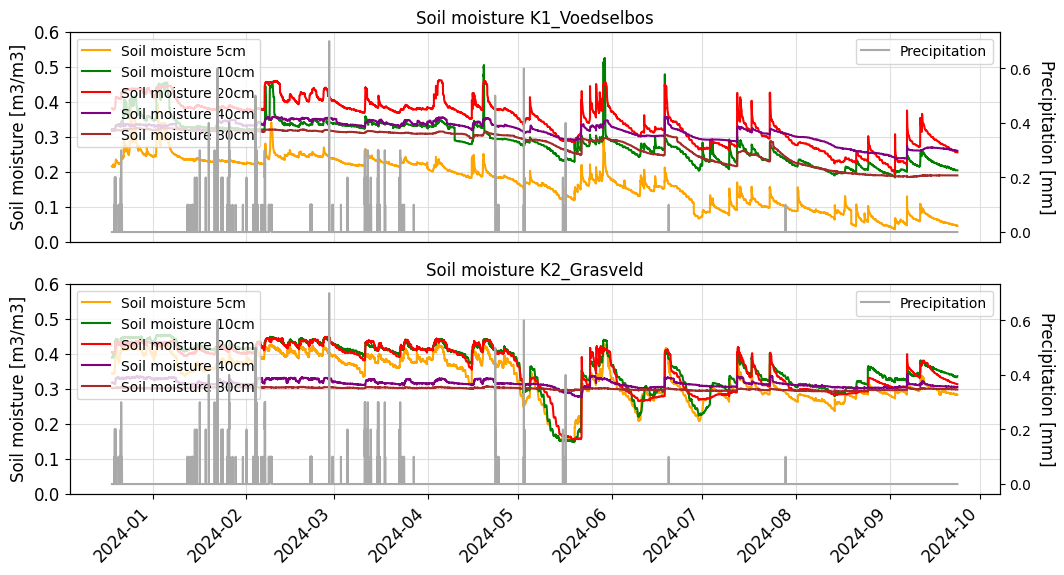

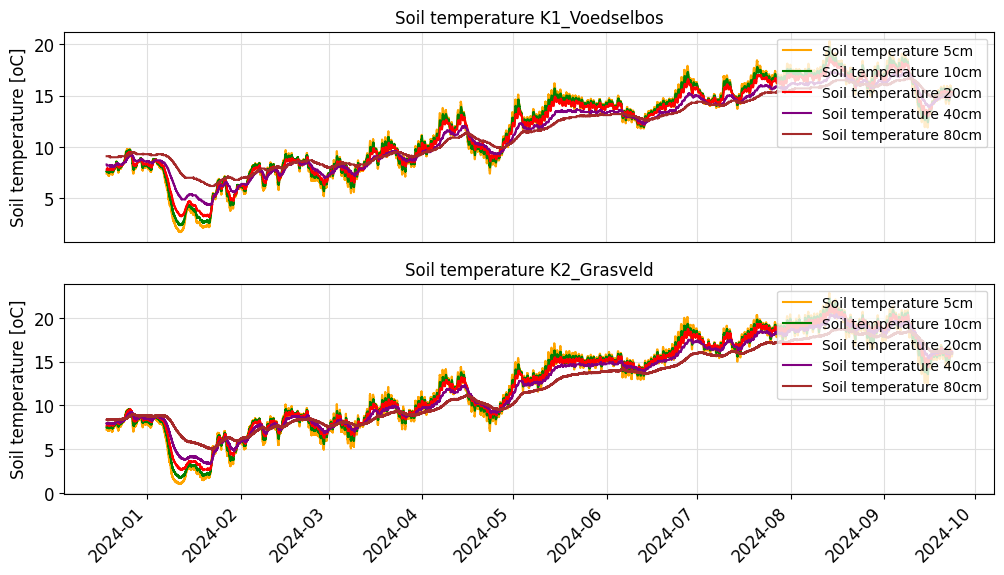

In [6]:
# Soil Moisture Plot
nr_loggers = len(soilmoisture)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilmoisture):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    msu.plotGraphPandas(logger_data, logger_id, unit, colorsSM)
    ax1.set_ylim(0,0.6)
    ax2 = ax1.twinx()
    ax2.plot(precipitation.index, precipitation['Precipitation observed'], label='Precipitation', color='darkgrey') #label=precipitation['parameter']
    legend = ax2.legend(loc='upper right', fontsize=10)
    ax2.set_ylabel('Precipitation [mm]', fontsize=12, rotation=270, verticalalignment='bottom')

# Soil Temperature Plot
nr_loggers = len(soilTemperature)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilTemperature):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    #ax1.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='darkgrey')
    msu.plotGraphPandas(logger_data, logger_id, unit, colorsST)
    legend = ax1.legend(loc='upper right', fontsize=10)

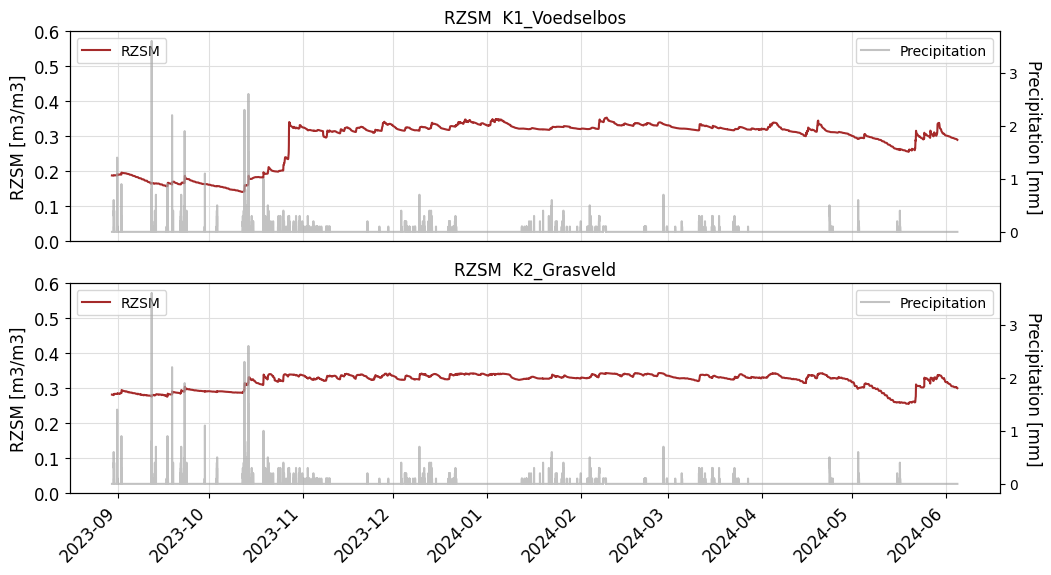

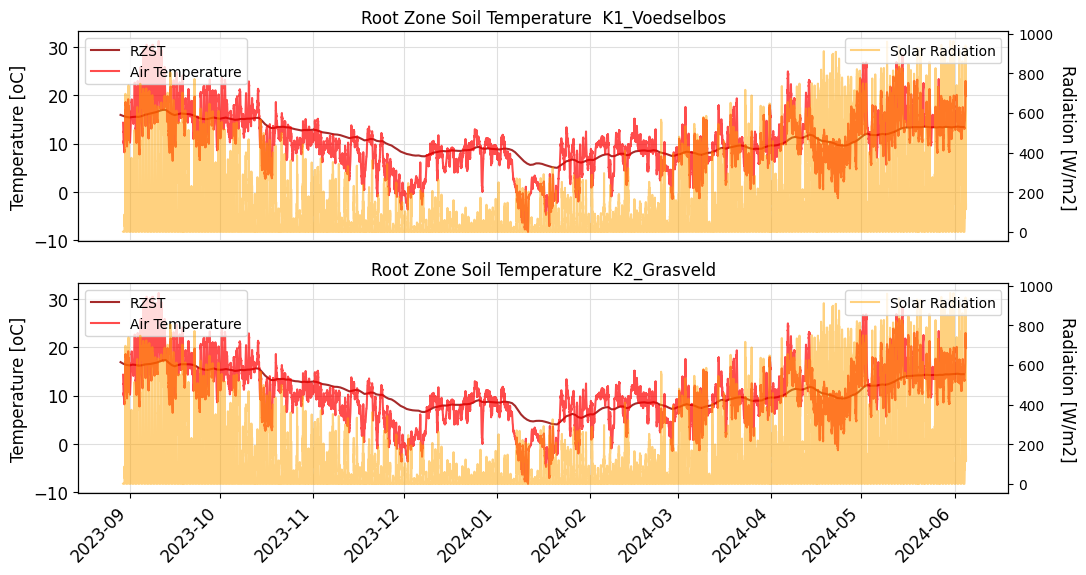

In [4]:
# Function defined for calculating depth-weighted root zone soil moisture/temperature
def getThicknesses(depths):
    thicknesses = []
    L_prev = 0 # top layer starts at surface
    for i in range(len(depths) - 1):
        L = (depths[i] + depths[i+1]) / 2.0
        thicknesses.append(L - L_prev)
        L_prev = L
    L = depths[-1] + depths[-1] / 2.0 # add the thickness of layer surrounding the 80cm depth
    thicknesses.append(L - L_prev)
    return thicknesses

def get_rzsm1(rec, cols, thicknesses): # in: soilmoistures: 1 vector with the values for every depth; thicknesses: 1 vector of same shape as soilmoistures
    rzsm = 2 * rec[cols[0]] * thicknesses[0]
    for i in range(1, len(cols)):
        rzsm = rzsm + (rec[cols[i-1]] + rec[cols[i]]) * thicknesses[i]
    rzsm = rzsm / (2 * sum(thicknesses))
    return rzsm

def get_rzsm2(rec, cols, thicknesses): # in: soilmoistures: 1 vector with the values for every depth; thicknesses: 1 vector of same shape as soilmoistures
    rzsm = 0
    for i in range(0, len(cols)):
        rzsm = rzsm + rec[cols[i]] * thicknesses[i]
    rzsm = rzsm / sum(thicknesses)
    return rzsm

# Root Zone Soil Moisture
nr_loggers = len(soilmoisture)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilmoisture):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.grid(visible=True, axis='both', color='#dfdfdf')
    if 'rzsm' in logger_data.columns: # so we can re-run this cell without error message
        logger_data.drop('rzsm', axis=1, inplace=True)
    sm_depths = []
    for parameter in logger_data.columns:
        sm_depths.append(float(parameter.split(' ')[-1][:-2]))
    sm_thicknesses = getThicknesses(sm_depths)
    logger_data['rzsm'] = logger_data.apply(lambda rec: get_rzsm2(rec, logger_data.columns, sm_thicknesses), axis=1)
    logger_data = logger_data.resample(timedelta(minutes=30)).mean()

    plt.plot(logger_data.index, logger_data['rzsm'], label='RZSM', color='brown')
    plt.ylabel('RZSM [m3/m3]', fontsize=12)
    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.title('RZSM ' + ' ' + logger_id[1], fontsize=12) #('RZSM ' + logger_id[0] + ' ' + logger_id[1], fontsize=12)
    legend = plt.legend(loc='upper left', fontsize=10)
    ax1.set_ylim(0,0.6)
    ax2 = ax1.twinx()
    ax2.plot(precipitation.index, precipitation['Precipitation observed'], label='Precipitation', color='darkgrey', alpha=0.7)
    legend = ax2.legend(loc='upper right', fontsize=10)
    ax2.set_ylabel('Precipitation [mm]', fontsize=12, rotation=270, verticalalignment='bottom')

# Root Zone Soil Temperature and Radiation
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilTemperature):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.grid(visible=True, axis='both', color='#dfdfdf')
    if 'rzst' in logger_data.columns: # so we can re-run this cell without error message
        logger_data.drop('rzst', axis=1, inplace=True)
    st_depths = []
    for parameter in logger_data.columns:
        st_depths.append(float(parameter.split(' ')[-1][:-2]))
    st_thicknesses = getThicknesses(st_depths)
    logger_data['rzst'] = logger_data.apply(lambda rec: get_rzsm2(rec, logger_data.columns, st_thicknesses), axis=1) # use same formula as SM; the formula is not SM-specific
    logger_data = logger_data.resample(timedelta(minutes=60*24)).mean()

    plt.plot(logger_data.index, logger_data['rzst'], label='RZST', color='brown')
    plt.ylabel('RZST [oC]', fontsize=12)
    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.title('Root Zone Soil Temperature ' + ' ' + logger_id[1], fontsize=12)
    plt.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='red', alpha=0.7)
    legend = plt.legend(loc='upper left', fontsize=10)
    ax1.set_ylabel('Temperature [oC]', fontsize=12)
    ax2 = ax1.twinx()
    ax2.plot(radiation.index, radiation['Radiation observation'], label='Solar Radiation', color='orange', alpha=0.5)
    legend = ax2.legend(loc='upper right', fontsize=10)
    ax2.set_ylabel('Radiation [W/m2]', fontsize=12, rotation=270, verticalalignment='bottom')
    


In [ ]:
# Vapor Pressure Deficit and air temperature
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(Vapor Pressure Deficit):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.grid(visible=True, axis='both', color='#dfdfdf')

    plt.plot(logger_data.index, logger_data['Vapor Pressure Deficit'], label='RZST', color='brown')
    plt.ylabel('RZST [oC]', fontsize=12)
    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.title('Root Zone Soil Temperature ' + ' ' + logger_id[1], fontsize=12)
    plt.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='red', alpha=0.7)
    legend = plt.legend(loc='upper left', fontsize=10)
    ax1.set_ylabel('Temperature [oC]', fontsize=12)
    ax2 = ax1.twinx()
    ax2.plot(radiation.index, radiation['Radiation observation'], label='Solar Radiation', color='orange', alpha=0.5)
    legend = ax2.legend(loc='upper right', fontsize=10)
    ax2.set_ylabel('Radiation [W/m2]', fontsize=12, rotation=270, verticalalignment='bottom')

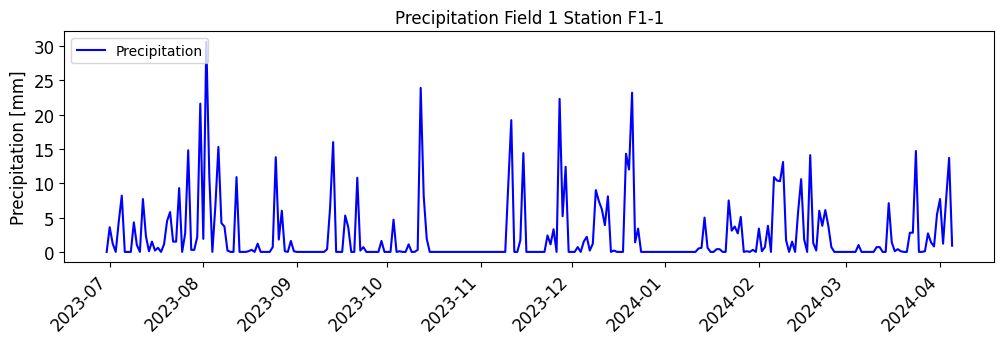

In [69]:
fig = plt.figure(figsize=(12, 3))
logger_id = loggers[0]
ax1 = plt.subplot(1, 1, 1)

resample = True
if resample:
    logger_data = precipitation.resample(timedelta(days=1)).sum() # resampled
else:
    logger_data = precipitation # use the original unresampled data

ax1.plot(logger_data.index, logger_data['Precipitation observed'], label='Precipitation', color='blue')
plt.ylabel('Precipitation [mm]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.title('Precipitation ' + logger_id[1], fontsize=12)
legend = plt.legend(loc='upper left', fontsize=10)

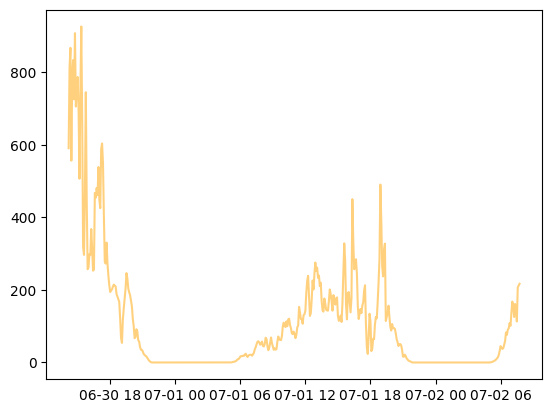

In [47]:
plt.plot(radiation.index[0:500], radiation['Radiation observation'][0:500], label='Solar Radiation', color='orange', alpha=0.5)

In [4]:
parameters = ['Vapor Pressure Deficit','Air Temperature observation'] # This should be vapor pressure deficit
loggers = [('z6-21180','K1_Voedselbos')]
#('z6-21180','K1_Voedselbos'),('z6-08819','K2_Grasveld')

In [5]:
data = msu.groupByParameter(timeseries, parameters, loggers)
data = msu.toPandas(data)

In [6]:
vaporPressure = data['Vapor Pressure Deficit'][0][2] # get the dataframe (not the location and the unit)
airTemperature = data['Air Temperature observation'][0][2] # same

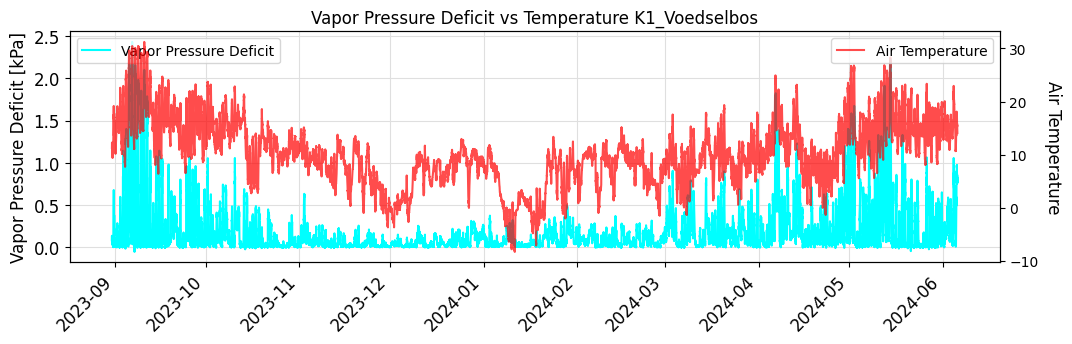

In [9]:
fig = plt.figure(figsize=(12, 3))
ax1 = plt.subplot(1, 1, 1)
plt.grid(visible=True, axis='both', color='#dfdfdf')
plt.plot(vaporPressure.index, vaporPressure['Vapor Pressure Deficit'], label='Vapor Pressure Deficit', color='cyan')
plt.ylabel('Vapor Pressure Deficit [kPa]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.title('Vapor Pressure Deficit vs Temperature K1_Voedselbos', fontsize=12)
legend = plt.legend(loc='upper left', fontsize=10)
ax2 = ax1.twinx()
ax2.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='red', alpha=0.7)
legend = ax2.legend(loc='upper right', fontsize=10)
label = ax2.set_ylabel('Air Temperature', fontsize=12, rotation=270, verticalalignment='bottom')

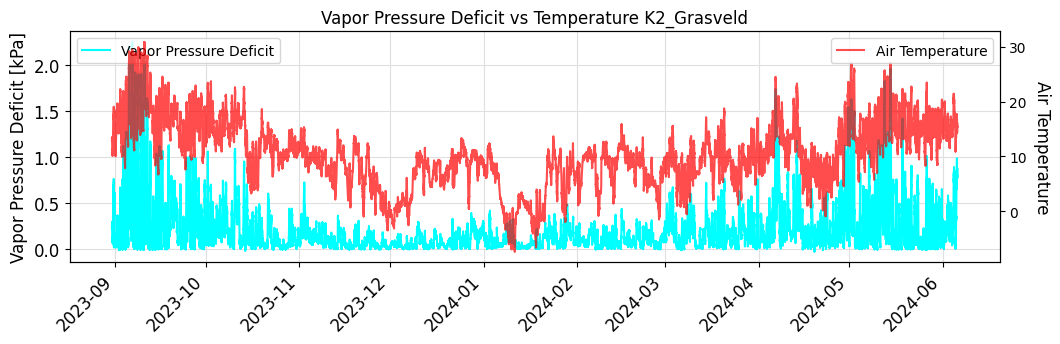

In [10]:
parameters = ['Vapor Pressure Deficit','Air Temperature observation'] # This should be vapor pressure deficit
loggers = [('z6-08819','K2_Grasveld')]
#('z6-21180','K1_Voedselbos'),('z6-08819','K2_Grasveld')
data = msu.groupByParameter(timeseries, parameters, loggers)
data = msu.toPandas(data)
vaporPressure = data['Vapor Pressure Deficit'][0][2] # get the dataframe (not the location and the unit)
airTemperature = data['Air Temperature observation'][0][2] # same
fig = plt.figure(figsize=(12, 3))
ax1 = plt.subplot(1, 1, 1)
plt.grid(visible=True, axis='both', color='#dfdfdf')
plt.plot(vaporPressure.index, vaporPressure['Vapor Pressure Deficit'], label='Vapor Pressure Deficit', color='cyan')
plt.ylabel('Vapor Pressure Deficit [kPa]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=45, fontsize=12, ha='right')
plt.title('Vapor Pressure Deficit vs Temperature K2_Grasveld', fontsize=12)
legend = plt.legend(loc='upper left', fontsize=10)
ax2 = ax1.twinx()
ax2.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='red', alpha=0.7)
legend = ax2.legend(loc='upper right', fontsize=10)
label = ax2.set_ylabel('Air Temperature', fontsize=12, rotation=270, verticalalignment='bottom')

# Action Points for Bas:
## Point 1
In the Soil Moisture Plots (including RZSM plot), please help fix the y-axis value range between min (0.0) and max (0.6)

### Added ax1.set_ylim(0,0.6) to all RZSM plots (the one before this cell, and the one after)

## Point 2
According to Bob, we shall try to plot all relevant observation variables together as below

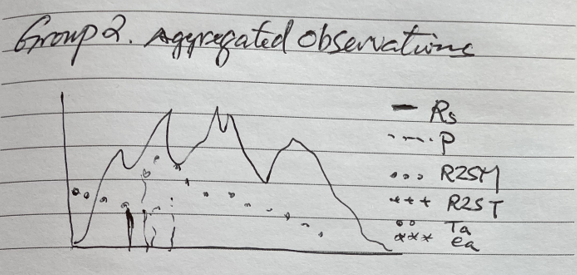

    As discussed, let's have the following plots:
    - (Plot a) For both Station 1 and Station 2, we pool Root Zone Soil Moisture, precipitation together
    - (Plot b) for both stations 1 and station 2, we pool Air Temperature (Ta), Root Zone Soil Temperature, and Solar Radiation. (Note that, Station 2 only have root zone soil temperature)
    - (Plot c) for station 1, put Vapor Pressure Deficit and Air Tempearture together. 

The above plots should be done for both Field 1 and Field 2.

## Point 3
Calculate the following equations (from Bob's notes):

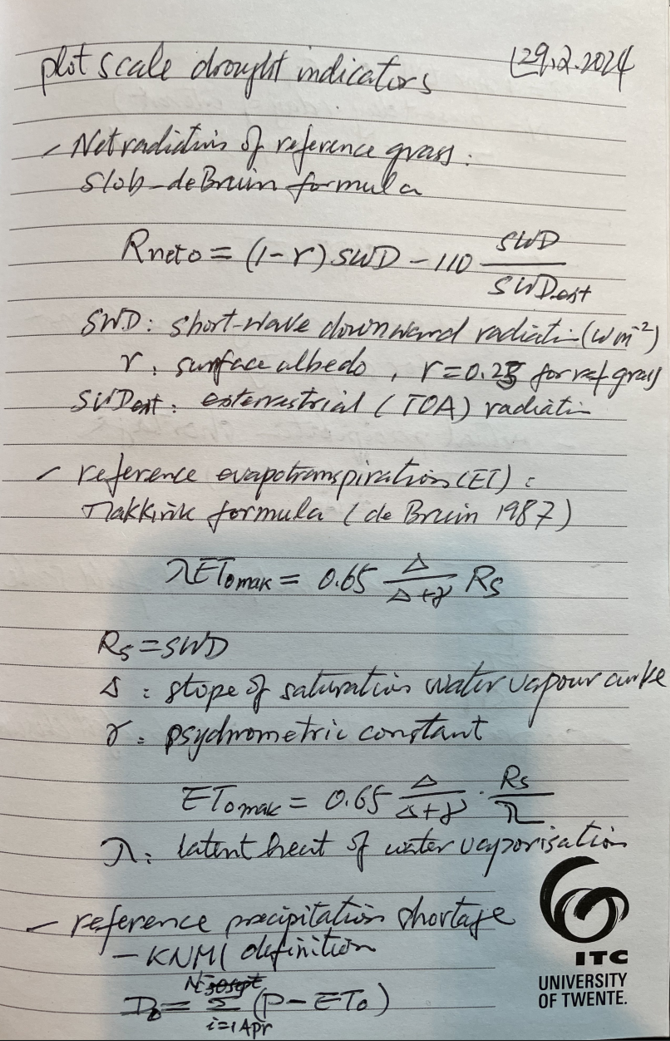
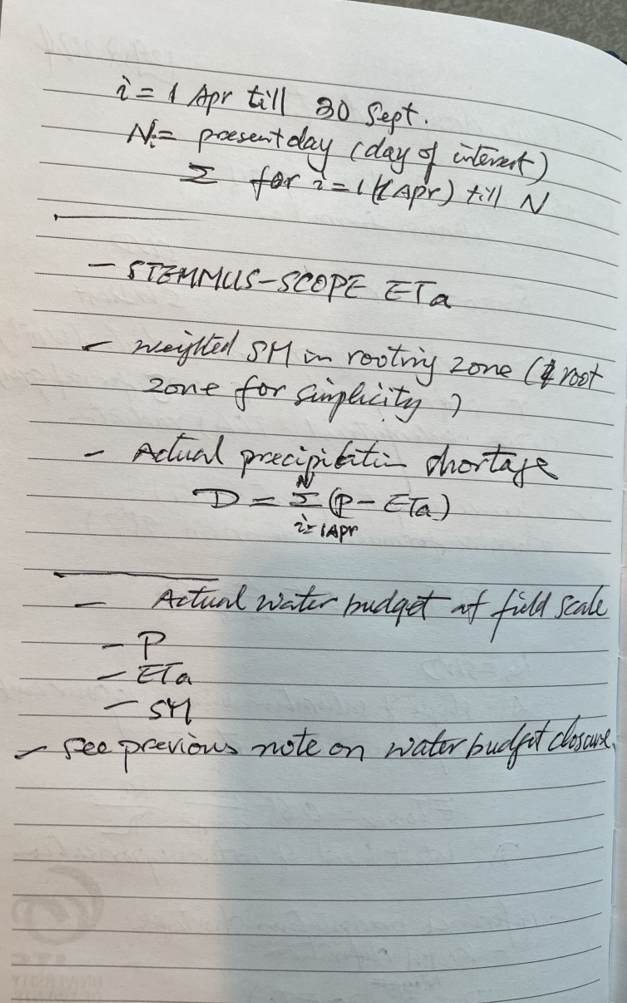

Mainly the equations on page 1.

### Figure 1: soil moisture at different depths together with Precipitation like below

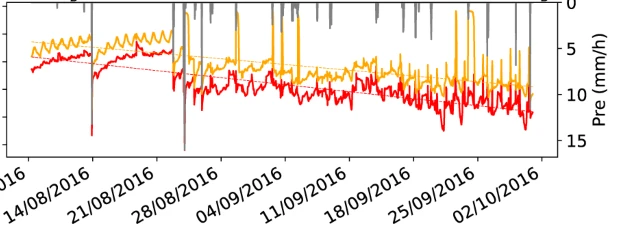

### Calculate Root Zone Soil Moisture as below

$RZSM=\dfrac{2𝜃_1𝐿_1+(𝜃_1+𝜃_2)𝐿_2+(𝜃_2+𝜃_3)𝐿_3+…+(𝜃_{𝑖−1}+𝜃_𝑖)𝐿_𝑖}{2(𝐿_1+𝐿_2+…+𝐿_𝑖)}$

where $𝑖$ is the index of the soil layer; $𝐿_𝑖$ [L] is the soil layer depth; and, $𝜃_𝑖$ [L3L−3] is soil moisture in the $𝑖$𝑡ℎ soil layer. The measurement depths are  5 cm, 10 cm, 20 cm, 40 cm, and 80 cm.

And add RZSM into the above figure.

The above we can plot for the whole time sereis, but also monthly and weekly

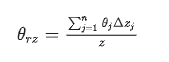

### Figure 2 Air temperature + Soil Tempearture at different depths, with a straight line of zero degree temperature somethinig like below, it is to note in ZentraCloud there is no 2.5cm temperature, and there is no soil surface temperature
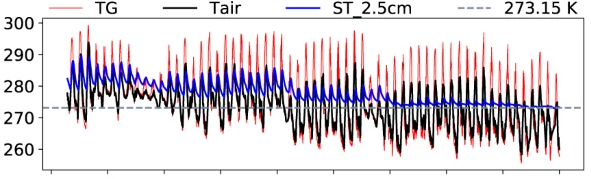

Also the above for the whole time series, and also monthly and weekly

### Precipitation from HOBO raingauge wth CSV files, resolution=0.2mm, meaning one tip

### Figure 3, WindRose map, something like below
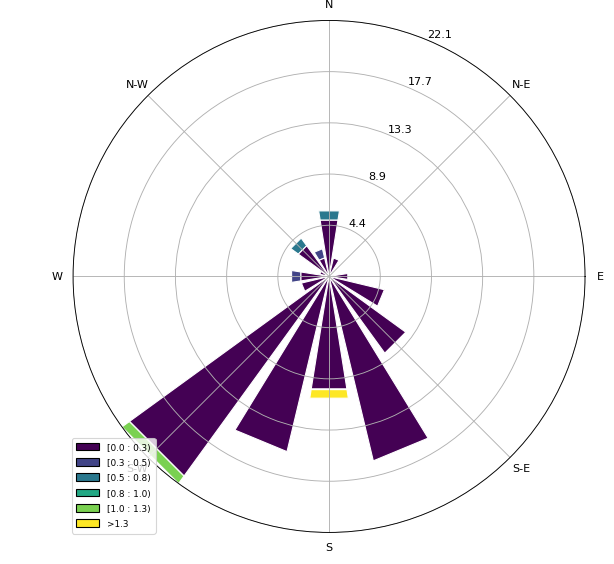


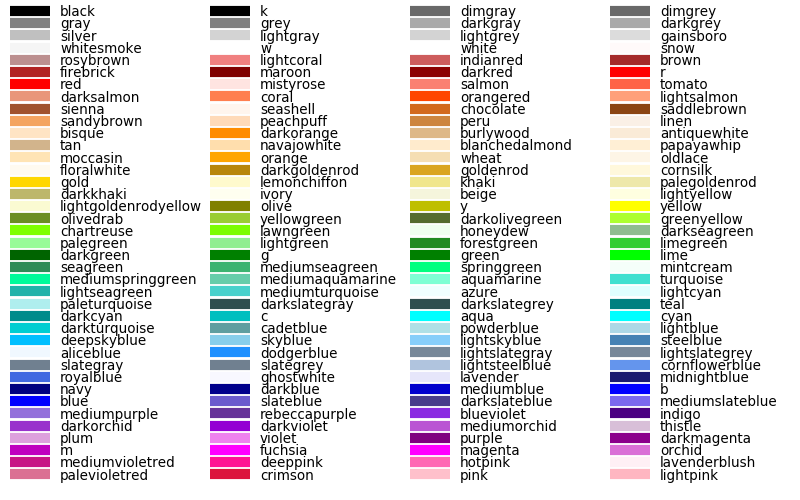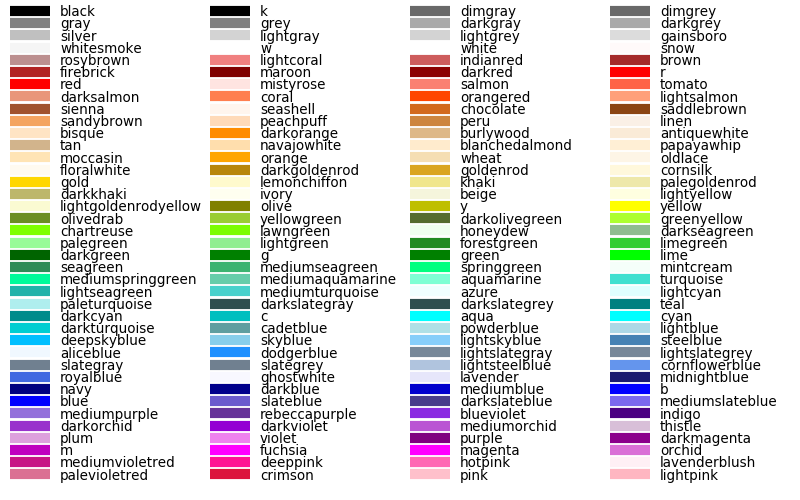

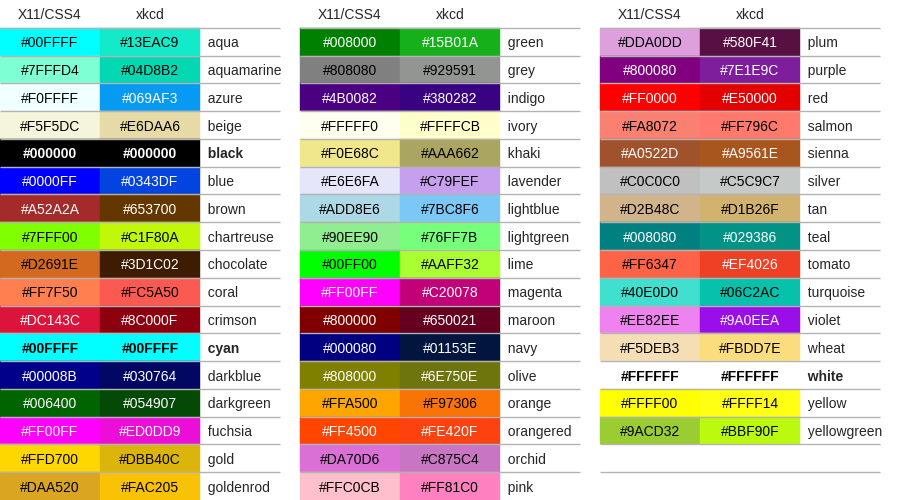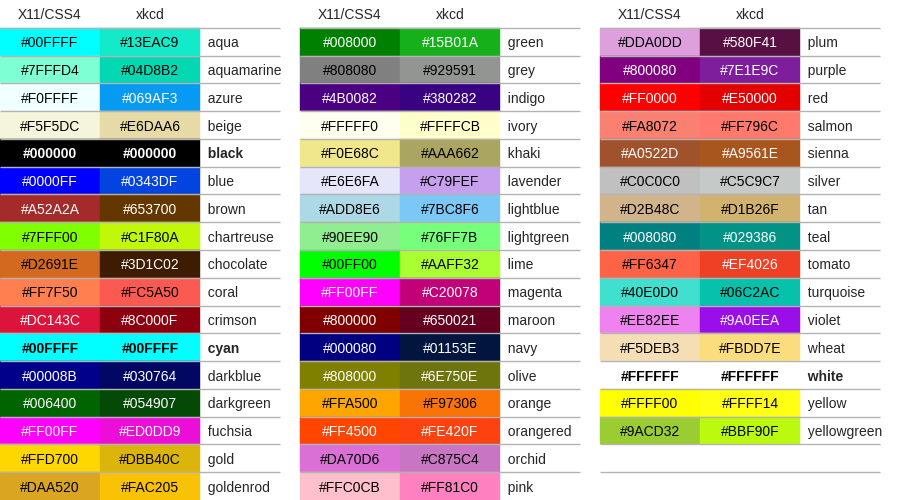

In [ ]:
colors = ['blue', 'orange',  'green', 'red', 'purple', 'brown']

In [ ]:
# Soil Moisture Plot
nr_loggers = len(soilmoisture)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilmoisture):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    msu.plotGraphPandas(logger_data, logger_id, unit)
    ax1.set_ylim(0,0.6)
    ax2 = ax1.twinx()
    ax2.plot(precipitation.index, precipitation['Precipitation observed'], label='Precipitation', color='darkgrey') #label=precipitation['parameter']
    legend = ax2.legend(loc='upper right', fontsize=10)
    ax2.set_ylabel('Precipitation [mm]', fontsize=12, rotation=270, verticalalignment='bottom')

# Soil Temperature Plot
nr_loggers = len(soilTemperature)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilTemperature):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    #ax1.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='darkgrey')
    msu.plotGraphPandas(logger_data, logger_id, unit)
    legend = ax1.legend(loc='upper right', fontsize=10)